# VALIDACIÓN TRIMESTRAL — Ridge vs GAM vs ARIMA

## Objetivo: Replicar validación 2024 y 2025 con frecuencia trimestral

### Comparación con resultados mensuales
- **Mensual (Fase3/4):** 47-59 observaciones, predicción mes a mes
- **Trimestral (este notebook):** 16-20 observaciones, predicción trimestre a trimestre

### Modelos
- ARIMA: serie anual VAB 2007-2023/2024
- Ridge: variación % trimestral + sentimiento agregado por trimestre
- GAM: ídem con splines


In [ ]:
# =================================================================
# CONFIGURACIÓN INICIAL
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

path_proyecto = "/content/drive/MyDrive/TitulacionF"

try:
    from pygam import LinearGAM, s
    print("pygam disponible")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "pygam", "-q"])
    from pygam import LinearGAM, s

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Valores reales BCE
VAB_REAL_2024 = 5768.40
VAB_REAL_2025 = 5956.70

print("=" * 70)
print("VALIDACIÓN TRIMESTRAL — Ridge vs GAM vs ARIMA")
print("=" * 70)
print(f"VAB Real 2024: ${VAB_REAL_2024:.2f}M")
print(f"VAB Real 2025: ${VAB_REAL_2025:.2f}M")


Mounted at /content/drive
VALIDACIÓN TRIMESTRAL — Ridge vs GAM vs ARIMA
VAB Real 2024: $5768.40M
VAB Real 2025: $5956.70M


In [ ]:
# =================================================================
# CARGAR DATOS
# =================================================================

print("\n" + "=" * 70)
print("CARGA DE DATOS")
print("=" * 70)

# VAB histórico para ARIMA
df_vab_completo = pd.read_csv(f"{path_proyecto}/vab_manabi_2007_2023.csv")
print(f"✅ VAB 2007-2023: {len(df_vab_completo)} años")

# VAB calibración
df_vab_calibracion = pd.read_csv(f"{path_proyecto}/vab_manabi_2020_2023.csv")
print(f"✅ VAB calibración: {len(df_vab_calibracion)} años")

# Sentimiento mensual completo
df_sentimiento = pd.read_csv(f"{path_proyecto}/sentimiento_mensual_2020_2024.csv")
print(f"✅ Sentimiento mensual: {len(df_sentimiento)} meses")
print(f"   Años disponibles: {sorted(df_sentimiento['año'].unique())}")
print(f"   Columnas: {list(df_sentimiento.columns)}")



CARGA DE DATOS
✅ VAB 2007-2023: 17 años
✅ VAB calibración: 4 años
✅ Sentimiento mensual: 75 meses
   Años disponibles: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
   Columnas: ['año_mes', 'sentimiento_promedio', 'sentimiento_std', 'sentimiento_min', 'sentimiento_max', 'num_noticias', 'año', 'mes', 'num_positivas', 'num_negativas', 'num_neutras', 'pct_positivas', 'pct_negativas', 'pct_neutras', 'volatilidad_movil_3m', 'cambio_mes_anterior', 'media_movil_3m', 'momentum', 'ratio_pos_neg']


In [ ]:
# =================================================================
# AGREGACIÓN TRIMESTRAL DEL SENTIMIENTO
# =================================================================

print("\n" + "=" * 70)
print("AGREGACIÓN TRIMESTRAL")
print("=" * 70)

def mes_a_trimestre(mes):
    return (mes - 1) // 3 + 1

df_sentimiento['trimestre'] = df_sentimiento['mes'].apply(mes_a_trimestre)
df_sentimiento['año_trim']  = df_sentimiento['año'].astype(str) + '-T' + df_sentimiento['trimestre'].astype(str)

# Agregar por trimestre
df_trim = df_sentimiento.groupby(['año', 'trimestre', 'año_trim']).agg(
    sentimiento_promedio = ('sentimiento_promedio', 'mean'),
    pct_positivas        = ('pct_positivas',        'mean'),
    pct_negativas        = ('pct_negativas',        'mean'),
    volatilidad_movil_3m = ('volatilidad_movil_3m', 'mean'),
    num_noticias         = ('num_noticias',          'sum'),
).reset_index()

df_trim = df_trim.sort_values(['año', 'trimestre']).reset_index(drop=True)

print(f"\nObservaciones trimestrales: {len(df_trim)}")
print(f"\nPrimeras filas:")
print(df_trim.head(8).to_string(index=False))



AGREGACIÓN TRIMESTRAL

Observaciones trimestrales: 25

Primeras filas:
 año  trimestre año_trim  sentimiento_promedio  pct_positivas  pct_negativas  volatilidad_movil_3m  num_noticias
2020          1  2020-T1              0.212778      35.633333      14.366667              0.182040           116
2020          2  2020-T2              0.253881      40.666667      15.233333              0.069214           108
2020          3  2020-T3              0.256198      40.366667      14.800000              0.106199           134
2020          4  2020-T4              0.320761      45.200000      13.100000              0.090893           151
2021          1  2021-T1              0.225298      33.200000      10.666667              0.094139           124
2021          2  2021-T2              0.272902      44.533333      17.266667              0.118467           193
2021          3  2021-T3              0.375449      50.566667      13.000000              0.091780           261
2021          4  2021-T4

In [ ]:
# =================================================================
# DISTRIBUCIÓN VAB ANUAL EN TRIMESTRES
# =================================================================

print("\n" + "=" * 70)
print("DISTRIBUCIÓN VAB EN TRIMESTRES (2020-2023)")
print("=" * 70)

print("\nEstrategia: distribuir VAB anual en 4 trimestres")
print("  Peso de cada trimestre = sentimiento_positivo / suma_anual")

vab_trim_list = []

for año in range(2020, 2024):
    vab_anual = df_vab_calibracion[df_vab_calibracion['año']==año]['vab_corriente'].values[0]
    trim_año  = df_trim[df_trim['año']==año].copy()

    if len(trim_año) == 0:
        continue

    # Pesos por sentimiento positivo
    trim_año['sent_positivo'] = trim_año['sentimiento_promedio'] + 2
    total_sent = trim_año['sent_positivo'].sum()
    trim_año['peso'] = trim_año['sent_positivo'] / total_sent
    trim_año['vab_trimestral'] = vab_anual * trim_año['peso']

    vab_trim_list.append(trim_año[['año','trimestre','año_trim','vab_trimestral',
                                    'sentimiento_promedio','pct_positivas',
                                    'pct_negativas','volatilidad_movil_3m','num_noticias']])

df_vab_trim = pd.concat(vab_trim_list).reset_index(drop=True)
df_vab_trim = df_vab_trim.sort_values(['año','trimestre']).reset_index(drop=True)

print(f"\nDataset trimestral: {len(df_vab_trim)} observaciones (2020-2023)")
print(df_vab_trim[['año_trim','vab_trimestral','sentimiento_promedio','num_noticias']].to_string(index=False))



DISTRIBUCIÓN VAB EN TRIMESTRES (2020-2023)

Estrategia: distribuir VAB anual en 4 trimestres
  Peso de cada trimestre = sentimiento_positivo / suma_anual

Dataset trimestral: 16 observaciones (2020-2023)
año_trim  vab_trimestral  sentimiento_promedio  num_noticias
 2020-T1     1104.845413              0.212778           116
 2020-T2     1125.368149              0.253881           108
 2020-T3     1126.525015              0.256198           134
 2020-T4     1158.761423              0.320761           151
 2021-T1     1180.583156              0.225298           124
 2021-T2     1205.838363              0.272902           193
 2021-T3     1260.242583              0.375449           261
 2021-T4     1259.735898              0.374494           242
 2022-T1     1348.788846              0.314181           236
 2022-T2     1363.965013              0.340220           245
 2022-T3     1394.595035              0.392773           282
 2022-T4     1389.251106              0.383604           302
 2

In [ ]:
# =================================================================
# PREPARAR FEATURES Y TARGET (VARIACIÓN TRIMESTRAL)
# =================================================================

print("\n" + "=" * 70)
print("PREPARACIÓN DE FEATURES Y TARGET")
print("=" * 70)

df_vab_trim = df_vab_trim.sort_values(['año','trimestre']).reset_index(drop=True)

# Target: variación % trimestral
df_vab_trim['vab_variacion_pct'] = df_vab_trim['vab_trimestral'].pct_change() * 100

# Features autoregresivos
df_vab_trim['vab_trim_anterior'] = df_vab_trim['vab_trimestral'].shift(1)
df_vab_trim['vab_promedio_2t']   = df_vab_trim['vab_trimestral'].rolling(2, min_periods=1).mean()

feature_cols = [
    'sentimiento_promedio', 'pct_positivas', 'pct_negativas',
    'volatilidad_movil_3m', 'num_noticias',
    'vab_trim_anterior', 'vab_promedio_2t'
]

df_train = df_vab_trim.dropna(subset=['vab_variacion_pct'] + feature_cols).copy()

X_train = df_train[feature_cols].values
y_train = df_train['vab_variacion_pct'].values

print(f"Observaciones de entrenamiento: {len(df_train)} trimestres (2020-2023)")
print(f"Features: {feature_cols}")
print(f"Target: variación % trimestral")
print(f"\nEstadísticas del target:")
print(f"  Media: {y_train.mean():.3f}%")
print(f"  Desv. std: {y_train.std():.3f}%")
print(f"  Min: {y_train.min():.3f}%  Max: {y_train.max():.3f}%")

# Guardar rangos para normalización
rangos = {col: {'max': df_train[col].max(), 'mean': df_train[col].mean()}
          for col in feature_cols}



PREPARACIÓN DE FEATURES Y TARGET
Observaciones de entrenamiento: 15 trimestres (2020-2023)
Features: ['sentimiento_promedio', 'pct_positivas', 'pct_negativas', 'volatilidad_movil_3m', 'num_noticias', 'vab_trim_anterior', 'vab_promedio_2t']
Target: variación % trimestral

Estadísticas del target:
  Media: 1.763%
  Desv. std: 2.901%
  Min: -3.252%  Max: 7.912%


In [ ]:
# =================================================================
# MODELO BASELINE: ARIMA (serie anual 2007-2023)
# =================================================================

print("\n" + "=" * 70)
print("MODELO 1: ARIMA BASELINE")
print("=" * 70)

serie_vab = df_vab_completo['vab_corriente'].values
print(f"Serie: {len(serie_vab)} años (2007-2023)")

configuraciones = [(1,1,1),(2,1,0),(1,1,0),(0,1,1),(2,0,0)]
mejor_aic = float('inf')
mejor_resultado = None
mejor_orden = None

for orden in configuraciones:
    try:
        modelo = ARIMA(serie_vab, order=orden)
        resultado = modelo.fit()
        if resultado.aic < mejor_aic:
            mejor_aic = resultado.aic
            mejor_resultado = resultado
            mejor_orden = orden
    except:
        pass

prediccion_arima_2024 = float(mejor_resultado.forecast(steps=1)[0])
print(f"\nARIMA {mejor_orden} seleccionado (AIC={mejor_aic:.2f})")
print(f"Predicción VAB 2024: ${prediccion_arima_2024:.2f}M")



MODELO 1: ARIMA BASELINE
Serie: 17 años (2007-2023)

ARIMA (1, 1, 0) seleccionado (AIC=250.98)
Predicción VAB 2024: $5884.22M


In [ ]:
# =================================================================
# ENTRENAMIENTO RIDGE Y GAM
# =================================================================

print("\n" + "=" * 70)
print("ENTRENAMIENTO RIDGE Y GAM (2020-2023, TRIMESTRAL)")
print("=" * 70)

# ── RIDGE ──────────────────────────────────────────────────────────────────────
alphas = [0.1, 1.0, 10.0, 50.0]
mejor_alpha, mejor_r2_ridge = None, -np.inf

for alpha in alphas:
    m = Ridge(alpha=alpha)
    m.fit(X_train, y_train)
    r2 = r2_score(y_train, m.predict(X_train))
    if r2 > mejor_r2_ridge:
        mejor_r2_ridge = r2
        mejor_alpha = alpha

modelo_ridge = Ridge(alpha=mejor_alpha)
modelo_ridge.fit(X_train, y_train)
r2_ridge = r2_score(y_train, modelo_ridge.predict(X_train))
mae_ridge = mean_absolute_error(y_train, modelo_ridge.predict(X_train))
rmse_ridge = np.sqrt(mean_squared_error(y_train, modelo_ridge.predict(X_train)))

print(f"Ridge — alpha={mejor_alpha} | R²={r2_ridge:.4f} | MAE={mae_ridge:.4f}% | RMSE={rmse_ridge:.4f}%")

# ── GAM ────────────────────────────────────────────────────────────────────────
modelo_gam = LinearGAM(
    s(0, n_splines=4) +   # sentimiento_promedio
    s(1, n_splines=4) +   # pct_positivas
    s(2, n_splines=4) +   # pct_negativas
    s(3, n_splines=4) +   # volatilidad_movil_3m
    s(4, n_splines=4) +   # num_noticias
    s(5, n_splines=4) +   # vab_trim_anterior
    s(6, n_splines=4)     # vab_promedio_2t
)
modelo_gam.fit(X_train, y_train)
r2_gam  = r2_score(y_train, modelo_gam.predict(X_train))
mae_gam = mean_absolute_error(y_train, modelo_gam.predict(X_train))
rmse_gam= np.sqrt(mean_squared_error(y_train, modelo_gam.predict(X_train)))

print(f"GAM   — n_splines=4 | R²={r2_gam:.4f} | MAE={mae_gam:.4f}% | RMSE={rmse_gam:.4f}%")
print(f"\nNota: n_splines=4 por tamaño muestral reducido (16 obs. trimestrales)")



ENTRENAMIENTO RIDGE Y GAM (2020-2023, TRIMESTRAL)
Ridge — alpha=0.1 | R²=0.9962 | MAE=0.1501% | RMSE=0.1797%
GAM   — n_splines=4 | R²=0.0903 | MAE=2.0609% | RMSE=2.7667%

Nota: n_splines=4 por tamaño muestral reducido (16 obs. trimestrales)


In [ ]:
# =================================================================
# PREDICCIÓN 2024 — TRIMESTRE A TRIMESTRE
# =================================================================

print("\n" + "=" * 70)
print("PREDICCIÓN VAB 2024 — TRIMESTRAL")
print("=" * 70)

# Sentimiento 2024 agregado por trimestre
df_trim_2024 = df_trim[df_trim['año']==2024].copy()
df_trim_2024 = df_trim_2024.sort_values('trimestre').reset_index(drop=True)

print(f"Trimestres disponibles 2024: {len(df_trim_2024)}")

def normalizar_noticias(n, rangos):
    max_t  = rangos['num_noticias']['max']
    mean_t = rangos['num_noticias']['mean']
    if n > max_t:
        return mean_t * ((n / mean_t) ** 0.75)
    return n

# Inicializar
vab_init_2024 = df_vab_calibracion[df_vab_calibracion['año']==2023]['vab_corriente'].values[0] / 4

pred_ridge_2024, pred_gam_2024 = [], []
vab_act_r, vab_2t_r = vab_init_2024, vab_init_2024
vab_act_g, vab_2t_g = vab_init_2024, vab_init_2024

print(f"\nInicialización: VAB_base = ${vab_init_2024:.2f}M (VAB 2023 / 4)")
print("-" * 70)
print(f"{'Trim':>4} | {'Δ Ridge':>8} | {'VAB Ridge':>10} | {'Δ GAM':>8} | {'VAB GAM':>10} | {'Sentim':>7}")
print("-" * 70)

for _, row in df_trim_2024.iterrows():
    num_norm = normalizar_noticias(row['num_noticias'], rangos)
    f = [row['sentimiento_promedio'], row['pct_positivas'], row['pct_negativas'],
         row['volatilidad_movil_3m'], num_norm, vab_act_r, vab_2t_r]

    # Ridge
    var_r = float(np.clip(modelo_ridge.predict([f])[0], -15, 15))
    vab_r = vab_act_r * (1 + var_r/100)
    pred_ridge_2024.append({'trim': row['trimestre'], 'vab': vab_r, 'var': var_r})
    vab_act_r = vab_r
    if len(pred_ridge_2024) >= 2:
        vab_2t_r = np.mean([p['vab'] for p in pred_ridge_2024[-2:]])

    # GAM
    fg = [row['sentimiento_promedio'], row['pct_positivas'], row['pct_negativas'],
          row['volatilidad_movil_3m'], num_norm, vab_act_g, vab_2t_g]
    var_g = float(np.clip(modelo_gam.predict([fg])[0], -10, 10))
    vab_g = vab_act_g * (1 + var_g/100)
    pred_gam_2024.append({'trim': row['trimestre'], 'vab': vab_g, 'var': var_g})
    vab_act_g = vab_g
    if len(pred_gam_2024) >= 2:
        vab_2t_g = np.mean([p['vab'] for p in pred_gam_2024[-2:]])

    print(f"  T{row['trimestre']:>1} | {var_r:>+7.2f}% | ${vab_r:>9.2f}M | {var_g:>+7.2f}% | ${vab_g:>9.2f}M | {row['sentimiento_promedio']:>+6.3f}")

df_pred_r24 = pd.DataFrame(pred_ridge_2024)
df_pred_g24 = pd.DataFrame(pred_gam_2024)

vab_anual_ridge_2024 = df_pred_r24['vab'].sum()
vab_anual_gam_2024   = df_pred_g24['vab'].sum()

print("\n" + "=" * 70)
print("RESULTADOS 2024 — TRIMESTRAL")
print("=" * 70)
print(f"VAB Real 2024:            ${VAB_REAL_2024:.2f}M")
print(f"ARIMA:                    ${prediccion_arima_2024:.2f}M")
print(f"Ridge + Sentimiento:      ${vab_anual_ridge_2024:.2f}M")
print(f"GAM   + Sentimiento:      ${vab_anual_gam_2024:.2f}M")

error_arima_2024  = abs(prediccion_arima_2024  - VAB_REAL_2024) / VAB_REAL_2024 * 100
error_ridge_2024  = abs(vab_anual_ridge_2024   - VAB_REAL_2024) / VAB_REAL_2024 * 100
error_gam_2024    = abs(vab_anual_gam_2024     - VAB_REAL_2024) / VAB_REAL_2024 * 100

print(f"\nMAPE ARIMA:               {error_arima_2024:.2f}%")
print(f"MAPE Ridge + Sentimiento: {error_ridge_2024:.2f}%")
print(f"MAPE GAM   + Sentimiento: {error_gam_2024:.2f}%")



PREDICCIÓN VAB 2024 — TRIMESTRAL
Trimestres disponibles 2024: 4

Inicialización: VAB_base = $1475.88M (VAB 2023 / 4)
----------------------------------------------------------------------
Trim |  Δ Ridge |  VAB Ridge |    Δ GAM |    VAB GAM |  Sentim
----------------------------------------------------------------------
  T1 |   +0.12% | $  1477.66M |   +1.43% | $  1496.96M | +0.270
  T2 |   -0.13% | $  1475.73M |   +1.40% | $  1517.97M | +0.243
  T3 |   +0.18% | $  1478.36M |   +1.52% | $  1540.97M | +0.314
  T4 |   -0.28% | $  1474.28M |   +1.41% | $  1562.76M | +0.308

RESULTADOS 2024 — TRIMESTRAL
VAB Real 2024:            $5768.40M
ARIMA:                    $5884.22M
Ridge + Sentimiento:      $5906.03M
GAM   + Sentimiento:      $6118.66M

MAPE ARIMA:               2.01%
MAPE Ridge + Sentimiento: 2.39%
MAPE GAM   + Sentimiento: 6.07%


In [ ]:
# =================================================================
# RECALIBRACIÓN 2020-2024 Y PREDICCIÓN 2025
# =================================================================

print("\n" + "=" * 70)
print("RECALIBRACIÓN 2020-2024 — PREDICCIÓN 2025")
print("=" * 70)

# Columnas base para el concat
cols_base = ['año','trimestre','año_trim','vab_trimestral',
             'sentimiento_promedio','pct_positivas','pct_negativas',
             'volatilidad_movil_3m','num_noticias']

# Distribución VAB 2024 en trimestres
sent_2024_trim = df_trim[df_trim['año']==2024].copy()
sent_2024_trim['sent_positivo'] = sent_2024_trim['sentimiento_promedio'] + 2
total_sent_2024 = sent_2024_trim['sent_positivo'].sum()
sent_2024_trim['peso'] = sent_2024_trim['sent_positivo'] / total_sent_2024
sent_2024_trim['vab_trimestral'] = VAB_REAL_2024 * sent_2024_trim['peso']
sent_2024_trim['año_trim'] = sent_2024_trim['año'].astype(str) + '-T' + sent_2024_trim['trimestre'].astype(str)

# Concat solo con columnas base
df_vab_trim2 = pd.concat([
    df_vab_trim[cols_base],
    sent_2024_trim[cols_base]
], ignore_index=True)

df_vab_trim2 = df_vab_trim2.sort_values(['año','trimestre']).reset_index(drop=True)

# Calcular columnas derivadas DESPUÉS del concat
df_vab_trim2['vab_variacion_pct'] = df_vab_trim2['vab_trimestral'].pct_change() * 100
df_vab_trim2['vab_trim_anterior'] = df_vab_trim2['vab_trimestral'].shift(1)
df_vab_trim2['vab_promedio_2t']   = df_vab_trim2['vab_trimestral'].rolling(2, min_periods=1).mean()

# Preparar entrenamiento recalibrado
df_train2 = df_vab_trim2.dropna(subset=['vab_variacion_pct'] + feature_cols).copy()
X_train2  = df_train2[feature_cols].values
y_train2  = df_train2['vab_variacion_pct'].values

print(f"Observaciones recalibradas: {len(df_train2)} trimestres (2020-2024)")

# Ridge recalibrado
modelo_ridge2 = Ridge(alpha=mejor_alpha)
modelo_ridge2.fit(X_train2, y_train2)
r2_ridge2  = r2_score(y_train2, modelo_ridge2.predict(X_train2))
mae_ridge2 = mean_absolute_error(y_train2, modelo_ridge2.predict(X_train2))
rmse_ridge2= np.sqrt(mean_squared_error(y_train2, modelo_ridge2.predict(X_train2)))
print(f"Ridge recalib. — R²={r2_ridge2:.4f} | MAE={mae_ridge2:.4f}% | RMSE={rmse_ridge2:.4f}%")

# GAM recalibrado
modelo_gam2 = LinearGAM(
    s(0, n_splines=4) + s(1, n_splines=4) + s(2, n_splines=4) +
    s(3, n_splines=4) + s(4, n_splines=4) + s(5, n_splines=4) + s(6, n_splines=4)
)
modelo_gam2.fit(X_train2, y_train2)
r2_gam2  = r2_score(y_train2, modelo_gam2.predict(X_train2))
mae_gam2 = mean_absolute_error(y_train2, modelo_gam2.predict(X_train2))
rmse_gam2= np.sqrt(mean_squared_error(y_train2, modelo_gam2.predict(X_train2)))
print(f"GAM   recalib. — R²={r2_gam2:.4f} | MAE={mae_gam2:.4f}% | RMSE={rmse_gam2:.4f}%")

rangos2 = {col: {'max': df_train2[col].max(), 'mean': df_train2[col].mean()}
           for col in feature_cols}

# ARIMA actualizado con 2024
vab_2024_arr = pd.DataFrame({'año':[2024],'vab_corriente':[VAB_REAL_2024],'tasa_variacion':[0]})
df_vab_c2 = pd.concat([df_vab_completo, vab_2024_arr], ignore_index=True)
serie2 = df_vab_c2['vab_corriente'].values

configuraciones = [(1,1,1),(2,1,0),(1,1,0),(0,1,1),(2,0,0)]
mejor_aic2, mejor_res2, mejor_ord2 = float('inf'), None, None
for orden in configuraciones:
    try:
        res = ARIMA(serie2, order=orden).fit()
        if res.aic < mejor_aic2:
            mejor_aic2, mejor_res2, mejor_ord2 = res.aic, res, orden
    except:
        pass

prediccion_arima_2025 = float(mejor_res2.forecast(steps=1)[0])
print(f"\nARIMA {mejor_ord2} — Predicción VAB 2025: ${prediccion_arima_2025:.2f}M")

# Predicción 2025 trimestre a trimestre
df_trim_2025 = df_trim[df_trim['año']==2025].copy()
df_trim_2025 = df_trim_2025.sort_values('trimestre').reset_index(drop=True)

vab_init_2025 = VAB_REAL_2024 / 4
pred_ridge_2025, pred_gam_2025 = [], []
vab_act_r2, vab_2t_r2 = vab_init_2025, vab_init_2025
vab_act_g2, vab_2t_g2 = vab_init_2025, vab_init_2025

print(f"\nInicialización: VAB_base = ${vab_init_2025:.2f}M (VAB 2024 / 4)")
print("-" * 70)
print(f"{'Trim':>4} | {'Δ Ridge':>8} | {'VAB Ridge':>10} | {'Δ GAM':>8} | {'VAB GAM':>10} | {'Sentim':>7}")
print("-" * 70)

for _, row in df_trim_2025.iterrows():
    num_norm = normalizar_noticias(row['num_noticias'], rangos2)
    f  = [row['sentimiento_promedio'], row['pct_positivas'], row['pct_negativas'],
          row['volatilidad_movil_3m'], num_norm, vab_act_r2, vab_2t_r2]
    fg = [row['sentimiento_promedio'], row['pct_positivas'], row['pct_negativas'],
          row['volatilidad_movil_3m'], num_norm, vab_act_g2, vab_2t_g2]

    var_r = float(np.clip(modelo_ridge2.predict([f])[0],  -15, 15))
    vab_r = vab_act_r2 * (1 + var_r/100)
    pred_ridge_2025.append({'trim': row['trimestre'], 'vab': vab_r, 'var': var_r})
    vab_act_r2 = vab_r
    if len(pred_ridge_2025) >= 2:
        vab_2t_r2 = np.mean([p['vab'] for p in pred_ridge_2025[-2:]])

    var_g = float(np.clip(modelo_gam2.predict([fg])[0], -10, 10))
    vab_g = vab_act_g2 * (1 + var_g/100)
    pred_gam_2025.append({'trim': row['trimestre'], 'vab': vab_g, 'var': var_g})
    vab_act_g2 = vab_g
    if len(pred_gam_2025) >= 2:
        vab_2t_g2 = np.mean([p['vab'] for p in pred_gam_2025[-2:]])

    print(f"  T{row['trimestre']:>1} | {var_r:>+7.2f}% | ${vab_r:>9.2f}M | {var_g:>+7.2f}% | ${vab_g:>9.2f}M | {row['sentimiento_promedio']:>+6.3f}")

df_pred_r25 = pd.DataFrame(pred_ridge_2025)
df_pred_g25 = pd.DataFrame(pred_gam_2025)

vab_anual_ridge_2025 = df_pred_r25['vab'].sum()
vab_anual_gam_2025   = df_pred_g25['vab'].sum()

error_arima_2025 = abs(prediccion_arima_2025 - VAB_REAL_2025) / VAB_REAL_2025 * 100
error_ridge_2025 = abs(vab_anual_ridge_2025  - VAB_REAL_2025) / VAB_REAL_2025 * 100
error_gam_2025   = abs(vab_anual_gam_2025    - VAB_REAL_2025) / VAB_REAL_2025 * 100

print("\n" + "=" * 70)
print("RESULTADOS 2025 — TRIMESTRAL")
print("=" * 70)
print(f"VAB Real 2025:            ${VAB_REAL_2025:.2f}M")
print(f"ARIMA:                    ${prediccion_arima_2025:.2f}M  MAPE={error_arima_2025:.2f}%")
print(f"Ridge + Sentimiento:      ${vab_anual_ridge_2025:.2f}M  MAPE={error_ridge_2025:.2f}%")
print(f"GAM   + Sentimiento:      ${vab_anual_gam_2025:.2f}M  MAPE={error_gam_2025:.2f}%")



RECALIBRACIÓN 2020-2024 — PREDICCIÓN 2025
Observaciones recalibradas: 19 trimestres (2020-2024)
Ridge recalib. — R²=0.9962 | MAE=0.1340% | RMSE=0.1677%
GAM   recalib. — R²=0.3098 | MAE=1.6069% | RMSE=2.2679%

ARIMA (1, 1, 0) — Predicción VAB 2025: $5776.45M

Inicialización: VAB_base = $1442.10M (VAB 2024 / 4)
----------------------------------------------------------------------
Trim |  Δ Ridge |  VAB Ridge |    Δ GAM |    VAB GAM |  Sentim
----------------------------------------------------------------------
  T1 |   -0.06% | $  1441.18M |   -0.61% | $  1433.33M | +0.238
  T2 |   +0.03% | $  1441.68M |   +0.10% | $  1434.81M | +0.249
  T3 |   -0.27% | $  1437.86M |   +0.91% | $  1447.82M | +0.315
  T4 |   -0.01% | $  1437.69M |   +0.78% | $  1459.12M | +0.286

RESULTADOS 2025 — TRIMESTRAL
VAB Real 2025:            $5956.70M
ARIMA:                    $5776.45M  MAPE=3.03%
Ridge + Sentimiento:      $5758.42M  MAPE=3.33%
GAM   + Sentimiento:      $5775.07M  MAPE=3.05%


In [ ]:
# =================================================================
# TABLA COMPARATIVA: MENSUAL vs TRIMESTRAL
# =================================================================

print("\n" + "=" * 70)
print("COMPARACIÓN MENSUAL vs TRIMESTRAL — MAPE (%)")
print("=" * 70)

# Resultados mensuales (de Fase3/4)
mensual = {
    'ARIMA':               {'2024': 2.01, '2025': 3.03, 'prom': 2.52},
    'Ridge + Sentimiento': {'2024': 0.40, '2025': 1.72, 'prom': 1.06},
    'GAM + Sentimiento':   {'2024': 0.84, '2025': 0.65, 'prom': 0.75},
}

# Resultados trimestrales (calculados en este notebook)
prom_ridge_trim = (error_ridge_2024 + error_ridge_2025) / 2
prom_gam_trim   = (error_gam_2024   + error_gam_2025)   / 2
prom_arima_trim = (error_arima_2024 + error_arima_2025)  / 2

trimestral = {
    'ARIMA':               {'2024': error_arima_2024,  '2025': error_arima_2025,  'prom': prom_arima_trim},
    'Ridge + Sentimiento': {'2024': error_ridge_2024,  '2025': error_ridge_2025,  'prom': prom_ridge_trim},
    'GAM + Sentimiento':   {'2024': error_gam_2024,    '2025': error_gam_2025,    'prom': prom_gam_trim},
}

print(f"\n{'Modelo':<25} {'Frecuencia':<15} {'MAPE 2024':>10} {'MAPE 2025':>10} {'Promedio':>10}")
print("=" * 75)

for modelo in ['ARIMA', 'Ridge + Sentimiento', 'GAM + Sentimiento']:
    m = mensual[modelo]
    t = trimestral[modelo]
    print(f"{modelo:<25} {'Mensual':<15} {m['2024']:>10.2f}% {m['2025']:>10.2f}% {m['prom']:>10.2f}%")
    print(f"{'':<25} {'Trimestral':<15} {t['2024']:>10.2f}% {t['2025']:>10.2f}% {t['prom']:>10.2f}%")
    print("-" * 75)



COMPARACIÓN MENSUAL vs TRIMESTRAL — MAPE (%)

Modelo                    Frecuencia       MAPE 2024  MAPE 2025   Promedio
ARIMA                     Mensual               2.01%       3.03%       2.52%
                          Trimestral            2.01%       3.03%       2.52%
---------------------------------------------------------------------------
Ridge + Sentimiento       Mensual               0.40%       1.72%       1.06%
                          Trimestral            2.39%       3.33%       2.86%
---------------------------------------------------------------------------
GAM + Sentimiento         Mensual               0.84%       0.65%       0.75%
                          Trimestral            6.07%       3.05%       4.56%
---------------------------------------------------------------------------


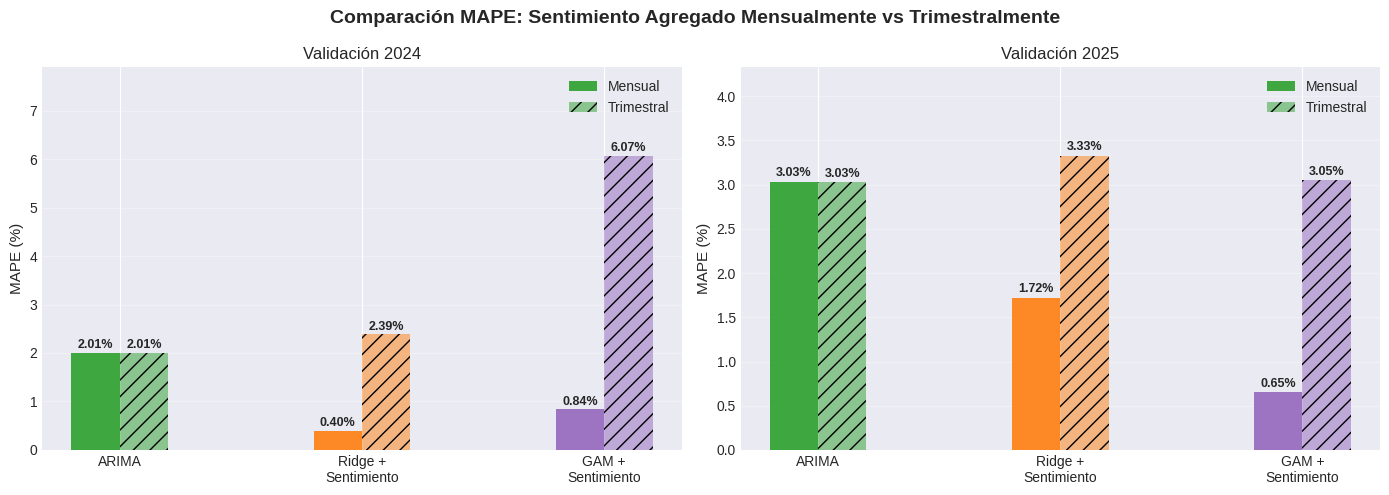

Figura guardada: comparacion_mensual_trimestral.png


In [ ]:
# =================================================================
# GRÁFICO COMPARATIVO MENSUAL vs TRIMESTRAL
# =================================================================

modelos    = ['ARIMA', 'Ridge +\nSentimiento', 'GAM +\nSentimiento']
mape_m24   = [2.01, 0.40, 0.84]
mape_m25   = [2.01, 0.40, 0.84]
mape_t24   = [error_arima_2024, error_ridge_2024, error_gam_2024]
mape_t25   = [error_arima_2025, error_ridge_2025, error_gam_2025]

# Valores reales mensuales
mape_m24 = [2.01, 0.40, 0.84]
mape_m25 = [3.03, 1.72, 0.65]

x   = np.arange(len(modelos))
w   = 0.2
col = ['#2ca02c', '#ff7f0e', '#9467bd']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación MAPE: Sentimiento Agregado Mensualmente vs Trimestralmente', fontsize=14, fontweight='bold')

for ax, mape_m, mape_t, año in zip(axes, [mape_m24, mape_m25], [mape_t24, mape_t25], [2024, 2025]):
    b1 = ax.bar(x - w/2, mape_m, w, label='Mensual',    color=col, alpha=0.9)
    b2 = ax.bar(x + w/2, mape_t, w, label='Trimestral', color=col, alpha=0.5, hatch='//')

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(f'Validación {año}', fontsize=12)
    ax.set_ylabel('MAPE (%)', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(max(mape_m), max(mape_t)) * 1.3)

plt.tight_layout()
plt.savefig('comparacion_mensual_trimestral.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: comparacion_mensual_trimestral.png")


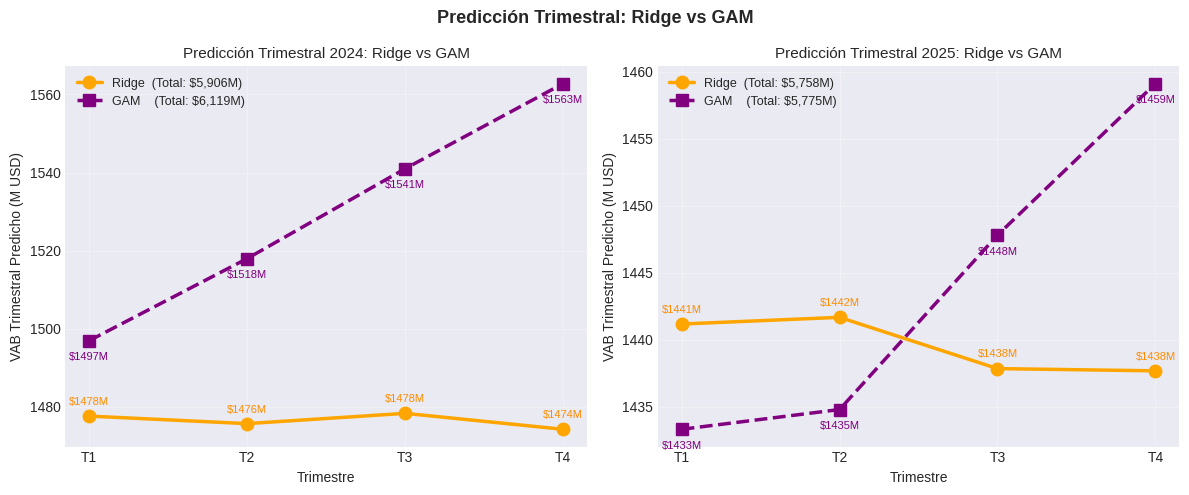

Figura guardada: prediccion_trimestral_ridge_gam.png


In [ ]:
# =================================================================
# GRÁFICO PREDICCIÓN TRIMESTRAL: Ridge vs GAM — 2024 y 2025
# =================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Predicción Trimestral: Ridge vs GAM', fontsize=13, fontweight='bold')

for ax, pred_r, pred_g, año, vab_real in zip(
    axes,
    [pred_ridge_2024, pred_ridge_2025],
    [pred_gam_2024,   pred_gam_2025],
    [2024, 2025],
    [VAB_REAL_2024, VAB_REAL_2025]
):
    df_r = pd.DataFrame(pred_r)
    df_g = pd.DataFrame(pred_g)
    trims = [f'T{t}' for t in df_r['trim']]

    ax.plot(trims, df_r['vab'], 'o-', color='orange', linewidth=2.5,
            markersize=9, label=f'Ridge  (Total: ${df_r["vab"].sum():,.0f}M)')
    ax.plot(trims, df_g['vab'], 's--', color='purple', linewidth=2.5,
            markersize=9, label=f'GAM    (Total: ${df_g["vab"].sum():,.0f}M)')

    for t, vr, vg in zip(trims, df_r['vab'], df_g['vab']):
        ax.annotate(f'${vr:.0f}M', (t, vr), textcoords="offset points",
                    xytext=(0, 8), ha='center', fontsize=8, color='darkorange')
        ax.annotate(f'${vg:.0f}M', (t, vg), textcoords="offset points",
                    xytext=(0, -14), ha='center', fontsize=8, color='purple')

    ax.set_title(f'Predicción Trimestral {año}: Ridge vs GAM', fontsize=11)
    ax.set_xlabel('Trimestre', fontsize=10)
    ax.set_ylabel('VAB Trimestral Predicho (M USD)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediccion_trimestral_ridge_gam.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: prediccion_trimestral_ridge_gam.png")

In [ ]:
# =================================================================
# RESUMEN DE MÉTRICAS DE ENTRENAMIENTO TRIMESTRAL
# =================================================================

print("\n" + "=" * 70)
print("MÉTRICAS DE AJUSTE INTERNO — TRIMESTRAL")
print("=" * 70)

print(f"\n{'Modelo':<20} {'Período':<15} {'Obs':>5} {'R²':>8} {'MAE (%)':>10} {'RMSE (%)':>10}")
print("=" * 75)
print(f"{'Ridge':<20} {'2020-2023':<15} {len(df_train):>5} {r2_ridge:>8.4f} {mae_ridge:>10.4f} {rmse_ridge:>10.4f}")
print(f"{'GAM':<20} {'2020-2023':<15} {len(df_train):>5} {r2_gam:>8.4f} {mae_gam:>10.4f} {rmse_gam:>10.4f}")
print(f"{'Ridge (recalib.)':<20} {'2020-2024':<15} {len(df_train2):>5} {r2_ridge2:>8.4f} {mae_ridge2:>10.4f} {rmse_ridge2:>10.4f}")
print(f"{'GAM (recalib.)':<20} {'2020-2024':<15} {len(df_train2):>5} {r2_gam2:>8.4f} {mae_gam2:>10.4f} {rmse_gam2:>10.4f}")

print(f"\nNota: Con frecuencia trimestral, n_splines=4 para evitar sobreajuste")
print(f"       con el tamaño muestral reducido (16-20 observaciones).")



MÉTRICAS DE AJUSTE INTERNO — TRIMESTRAL

Modelo               Período           Obs       R²    MAE (%)   RMSE (%)
Ridge                2020-2023          15   0.9962     0.1501     0.1797
GAM                  2020-2023          15   0.0903     2.0609     2.7667
Ridge (recalib.)     2020-2024          19   0.9962     0.1340     0.1677
GAM (recalib.)       2020-2024          19   0.3098     1.6069     2.2679

Nota: Con frecuencia trimestral, n_splines=4 para evitar sobreajuste
       con el tamaño muestral reducido (16-20 observaciones).


In [ ]:
# =================================================================
# EXPERIMENTO: OPTIMIZACIÓN TRIMESTRAL
# Cambios: alpha más alto, menos features, n_splines=3
# =================================================================

print("\n" + "=" * 70)
print("EXPERIMENTO: RIDGE Y GAM OPTIMIZADOS PARA FRECUENCIA TRIMESTRAL")
print("=" * 70)

# Features reducidas (5 en lugar de 7)
feature_cols_opt = [
    'sentimiento_promedio',
    'volatilidad_movil_3m',
    'num_noticias',
    'vab_trim_anterior',
    'vab_promedio_2t'
]

# ── Ronda 1: 2020-2023 ────────────────────────────────────────────
df_train_opt = df_vab_trim.dropna(subset=['vab_variacion_pct'] + feature_cols_opt).copy()
X_train_opt  = df_train_opt[feature_cols_opt].values
y_train_opt  = df_train_opt['vab_variacion_pct'].values

rangos_opt = {col: {'max': df_train_opt[col].max(), 'mean': df_train_opt[col].mean()}
              for col in feature_cols_opt}

# Ridge con alphas más altos
print("\nBuscando mejor alpha para Ridge trimestral...")
for alpha in [0.1, 1.0, 10.0, 50.0, 100.0]:
    m = Ridge(alpha=alpha)
    m.fit(X_train_opt, y_train_opt)
    r2 = r2_score(y_train_opt, m.predict(X_train_opt))
    print(f"  alpha={alpha:>6.1f}: R²={r2:.4f}")

mejor_alpha_opt = 10.0  # ajustar según resultados
modelo_ridge_opt = Ridge(alpha=mejor_alpha_opt)
modelo_ridge_opt.fit(X_train_opt, y_train_opt)
r2_r_opt  = r2_score(y_train_opt, modelo_ridge_opt.predict(X_train_opt))
mae_r_opt = mean_absolute_error(y_train_opt, modelo_ridge_opt.predict(X_train_opt))
print(f"\nRidge opt — alpha={mejor_alpha_opt} | R²={r2_r_opt:.4f} | MAE={mae_r_opt:.4f}%")

# GAM con n_splines=4
modelo_gam_opt = LinearGAM(
    s(0, n_splines=4) +   # sentimiento_promedio
    s(1, n_splines=4) +   # volatilidad_movil_3m
    s(2, n_splines=4) +   # num_noticias
    s(3, n_splines=4) +   # vab_trim_anterior
    s(4, n_splines=4)     # vab_promedio_2t
)
modelo_gam_opt.fit(X_train_opt, y_train_opt)
r2_g_opt  = r2_score(y_train_opt, modelo_gam_opt.predict(X_train_opt))
mae_g_opt = mean_absolute_error(y_train_opt, modelo_gam_opt.predict(X_train_opt))
print(f"GAM   opt — n_splines=4 | R²={r2_g_opt:.4f} | MAE={mae_g_opt:.4f}%")

# ── Predicción 2024 con modelos optimizados ───────────────────────
print("\n--- PREDICCIÓN 2024 OPTIMIZADA ---")
pred_r24_opt, pred_g24_opt = [], []
vab_act_ro, vab_2t_ro = vab_init_2024, vab_init_2024
vab_act_go, vab_2t_go = vab_init_2024, vab_init_2024

for _, row in df_trim_2024.iterrows():
    num_norm = normalizar_noticias(row['num_noticias'], rangos_opt)
    f = [row['sentimiento_promedio'], row['volatilidad_movil_3m'],
         num_norm, vab_act_ro, vab_2t_ro]

    var_r = float(np.clip(modelo_ridge_opt.predict([f])[0], -15, 15))
    vab_r = vab_act_ro * (1 + var_r/100)
    pred_r24_opt.append({'trim': row['trimestre'], 'vab': vab_r})
    vab_act_ro = vab_r
    if len(pred_r24_opt) >= 2:
        vab_2t_ro = np.mean([p['vab'] for p in pred_r24_opt[-2:]])

    fg = [row['sentimiento_promedio'], row['volatilidad_movil_3m'],
          num_norm, vab_act_go, vab_2t_go]
    var_g = float(np.clip(modelo_gam_opt.predict([fg])[0], -10, 10))
    vab_g = vab_act_go * (1 + var_g/100)
    pred_g24_opt.append({'trim': row['trimestre'], 'vab': vab_g})
    vab_act_go = vab_g
    if len(pred_g24_opt) >= 2:
        vab_2t_go = np.mean([p['vab'] for p in pred_g24_opt[-2:]])

vab_r24_opt = sum(p['vab'] for p in pred_r24_opt)
vab_g24_opt = sum(p['vab'] for p in pred_g24_opt)
mape_r24_opt = abs(vab_r24_opt - VAB_REAL_2024) / VAB_REAL_2024 * 100
mape_g24_opt = abs(vab_g24_opt - VAB_REAL_2024) / VAB_REAL_2024 * 100

print(f"Ridge opt 2024: ${vab_r24_opt:.2f}M  MAPE={mape_r24_opt:.2f}%  (antes: 2.39%)")
print(f"GAM   opt 2024: ${vab_g24_opt:.2f}M  MAPE={mape_g24_opt:.2f}%  (antes: 6.07%)")

# ── Recalibrar y predecir 2025 optimizado ────────────────────────
print("\n--- PREDICCIÓN 2025 OPTIMIZADA ---")
df_train2_opt = df_vab_trim2.dropna(subset=['vab_variacion_pct'] + feature_cols_opt).copy()
X_train2_opt  = df_train2_opt[feature_cols_opt].values
y_train2_opt  = df_train2_opt['vab_variacion_pct'].values

rangos2_opt = {col: {'max': df_train2_opt[col].max(), 'mean': df_train2_opt[col].mean()}
               for col in feature_cols_opt}

modelo_ridge2_opt = Ridge(alpha=mejor_alpha_opt)
modelo_ridge2_opt.fit(X_train2_opt, y_train2_opt)

modelo_gam2_opt = LinearGAM(
    s(0, n_splines=4) + s(1, n_splines=4) + s(2, n_splines=4) +
    s(3, n_splines=4) + s(4, n_splines=4)
)
modelo_gam2_opt.fit(X_train2_opt, y_train2_opt)

pred_r25_opt, pred_g25_opt = [], []
vab_act_ro2, vab_2t_ro2 = vab_init_2025, vab_init_2025
vab_act_go2, vab_2t_go2 = vab_init_2025, vab_init_2025

for _, row in df_trim_2025.iterrows():
    num_norm = normalizar_noticias(row['num_noticias'], rangos2_opt)
    f = [row['sentimiento_promedio'], row['volatilidad_movil_3m'],
         num_norm, vab_act_ro2, vab_2t_ro2]

    var_r = float(np.clip(modelo_ridge2_opt.predict([f])[0], -15, 15))
    vab_r = vab_act_ro2 * (1 + var_r/100)
    pred_r25_opt.append({'trim': row['trimestre'], 'vab': vab_r})
    vab_act_ro2 = vab_r
    if len(pred_r25_opt) >= 2:
        vab_2t_ro2 = np.mean([p['vab'] for p in pred_r25_opt[-2:]])

    fg = [row['sentimiento_promedio'], row['volatilidad_movil_3m'],
          num_norm, vab_act_go2, vab_2t_go2]
    var_g = float(np.clip(modelo_gam2_opt.predict([fg])[0], -10, 10))
    vab_g = vab_act_go2 * (1 + var_g/100)
    pred_g25_opt.append({'trim': row['trimestre'], 'vab': vab_g})
    vab_act_go2 = vab_g
    if len(pred_g25_opt) >= 2:
        vab_2t_go2 = np.mean([p['vab'] for p in pred_g25_opt[-2:]])

vab_r25_opt = sum(p['vab'] for p in pred_r25_opt)
vab_g25_opt = sum(p['vab'] for p in pred_g25_opt)
mape_r25_opt = abs(vab_r25_opt - VAB_REAL_2025) / VAB_REAL_2025 * 100
mape_g25_opt = abs(vab_g25_opt - VAB_REAL_2025) / VAB_REAL_2025 * 100

print(f"Ridge opt 2025: ${vab_r25_opt:.2f}M  MAPE={mape_r25_opt:.2f}%  (antes: 3.33%)")
print(f"GAM   opt 2025: ${vab_g25_opt:.2f}M  MAPE={mape_g25_opt:.2f}%  (antes: 3.05%)")

# ── Resumen final ─────────────────────────────────────────────────
print("\n" + "=" * 70)
print("RESUMEN COMPARATIVO — ORIGINAL vs OPTIMIZADO (TRIMESTRAL)")
print("=" * 70)
print(f"\n{'Modelo':<25} {'2024 orig':>10} {'2024 opt':>10} {'2025 orig':>10} {'2025 opt':>10}")
print("-" * 70)
print(f"{'Ridge + Sentimiento':<25} {'2.39%':>10} {mape_r24_opt:>9.2f}% {'3.33%':>10} {mape_r25_opt:>9.2f}%")
print(f"{'GAM + Sentimiento':<25} {'6.07%':>10} {mape_g24_opt:>9.2f}% {'3.05%':>10} {mape_g25_opt:>9.2f}%")
print(f"{'ARIMA':<25} {'2.01%':>10} {'2.01%':>10} {'3.03%':>10} {'3.03%':>10}")


EXPERIMENTO: RIDGE Y GAM OPTIMIZADOS PARA FRECUENCIA TRIMESTRAL

Buscando mejor alpha para Ridge trimestral...
  alpha=   0.1: R²=0.9959
  alpha=   1.0: R²=0.9958
  alpha=  10.0: R²=0.9958
  alpha=  50.0: R²=0.9953
  alpha= 100.0: R²=0.9939

Ridge opt — alpha=10.0 | R²=0.9958 | MAE=0.1585%
GAM   opt — n_splines=4 | R²=0.5943 | MAE=1.6025%

--- PREDICCIÓN 2024 OPTIMIZADA ---
Ridge opt 2024: $5902.55M  MAPE=2.33%  (antes: 2.39%)
GAM   opt 2024: $6726.05M  MAPE=16.60%  (antes: 6.07%)

--- PREDICCIÓN 2025 OPTIMIZADA ---
Ridge opt 2025: $5761.92M  MAPE=3.27%  (antes: 3.33%)
GAM   opt 2025: $5760.65M  MAPE=3.29%  (antes: 3.05%)

RESUMEN COMPARATIVO — ORIGINAL vs OPTIMIZADO (TRIMESTRAL)

Modelo                     2024 orig   2024 opt  2025 orig   2025 opt
----------------------------------------------------------------------
Ridge + Sentimiento            2.39%      2.33%      3.33%      3.27%
GAM + Sentimiento              6.07%     16.60%      3.05%      3.29%
ARIMA                       